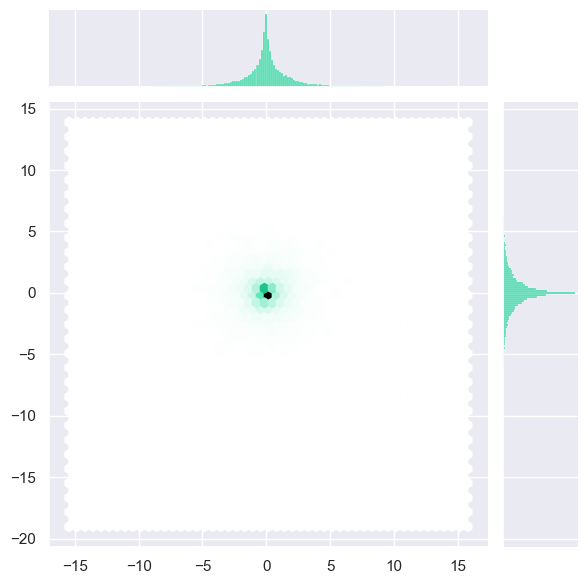

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#simulate 10,000 random particle impact coordinates hitting a circular detector sensor
angles=np.random.uniform(0,2*np.pi,10000)
radii=np.random.exponential(scale=2.0, size=10000)
x=radii*np.cos(angles)
y=radii*np.sin(angles)

#use seaborn to instantly plot a high-density heatmap of the partical impacts
sns.set_theme(style="darkgrid")
sns.jointplot(x=x,y=y,kind="hex",color="#0F7955")
plt.show()

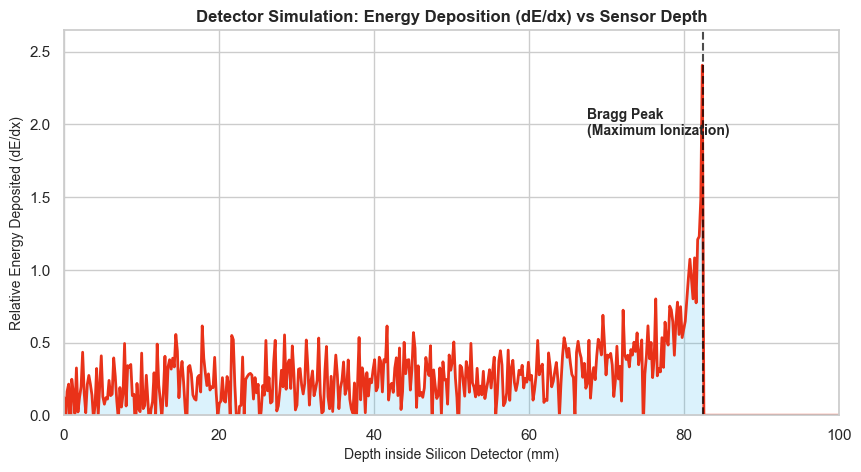

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for a clean engineering look
sns.set_theme(style="whitegrid")

# 1. Define physical properties of the system
detector_depth_mm = 100  # Total depth of the detector material
steps = 500             # Slices of space we track the particle through
x_positions = np.linspace(0, detector_depth_mm, steps)

# 2. Simulate Bethe-Bloch energy deposition math (simplified)
# As the particle slows down (depth increases), its energy deposition increases dramatically
stopping_point = 82.5   # The exact depth where the particle runs out of speed
energy_loss = []

for x in x_positions:
    if x < stopping_point:
        # Energy loss is inversely proportional to the remaining distance to stopping point
        loss = 1.0 / (stopping_point - x)**0.4 + np.random.normal(0, 0.15)
    else:
        # Once the particle stops, it deposits zero energy
        loss = 0.0
    energy_loss.append(loss)

energy_loss = np.array(energy_loss)

# 3. Plot the Detector Simulation readout
plt.figure(figsize=(10, 5))
plt.plot(x_positions, energy_loss, color="#E93219", lw=2, label='Simulated Particle Track Data')
plt.fill_between(x_positions, energy_loss, color="#11AEEC", alpha=0.15)

# Highlight the Bragg Peak
plt.axvline(x=stopping_point, color='black', linestyle='--', alpha=0.7)
plt.text(stopping_point - 15, max(energy_loss)*0.8, 'Bragg Peak\n(Maximum Ionization)', fontsize=10, weight='bold')

# Formatting labels
plt.title('Detector Simulation: Energy Deposition (dE/dx) vs Sensor Depth', fontsize=12, weight='bold')
plt.xlabel('Depth inside Silicon Detector (mm)', fontsize=10)
plt.ylabel('Relative Energy Deposited (dE/dx)', fontsize=10)
plt.xlim(0, detector_depth_mm)
plt.ylim(0, max(energy_loss) * 1.1)
plt.show()

=== Geometry only ===
Detector 1 hits: 10000
Detector 2 hits: 2667
Geometry coincidences: 2667


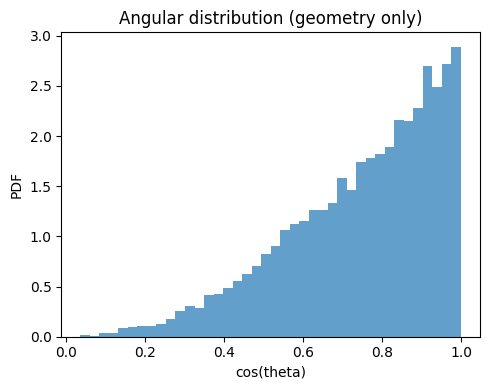

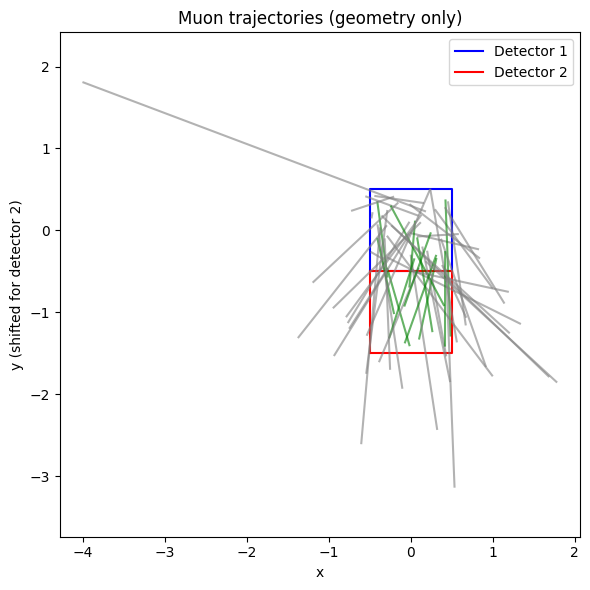


=== Geometry + energy loss ===
Hits in detector 1: 10000
Hits in detector 2: 2667
Muons that survive to detector 2: 7721
Coincidences with survival: 2100


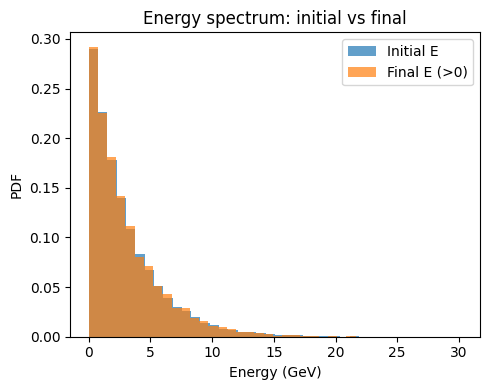

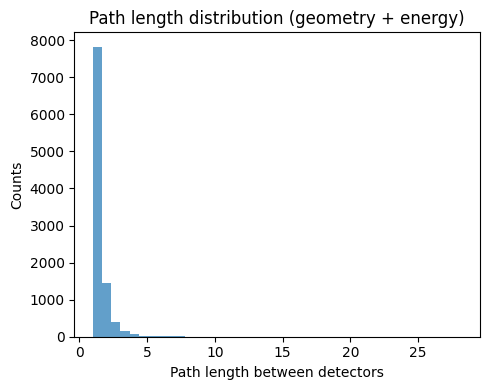


=== Full time-series with noise ===
Total hits in detector 1: 719
Total hits in detector 2: 235
True coincidences: 118
Accidental coincidences: 0
Expected accidental coincidences (rough): 0.24


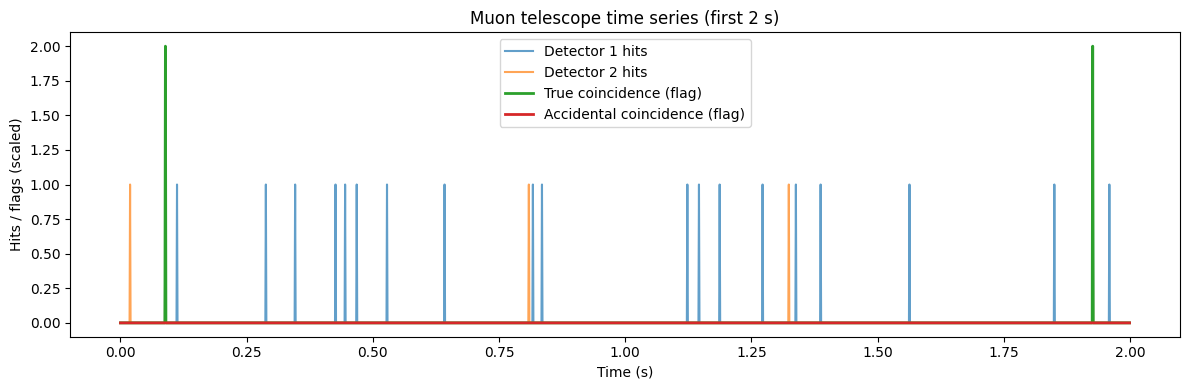

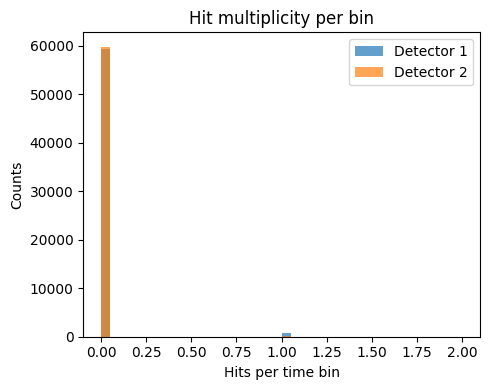

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ============================================
# Helper: angular and energy sampling
# ============================================

def sample_theta():
    """Sample zenith angle with PDF(cosθ) ∝ cos²θ, 0 ≤ θ ≤ π/2."""
    while True:
        x = np.random.uniform(0, 1)  # candidate cos(theta)
        y = np.random.uniform(0, 1)
        if y < x**2:
            return np.arccos(x)

def sample_theta_array(N):
    return np.array([sample_theta() for _ in range(N)])

def sample_energy_exp(N, E0):
    """Exponential energy spectrum with scale E0."""
    u = np.random.uniform(0, 1, size=N)
    return -E0 * np.log(1 - u)

# ============================================
# 1) GEOMETRY ONLY
# ============================================

N = 10000         # number of muons
L = 1.0           # detector side length
d = 1.0           # separation

theta = sample_theta_array(N)
phi = np.random.uniform(0, 2*np.pi, N)

# Position where muons cross detector 1 plane
x1 = np.random.uniform(-L/2, L/2, N)
y1 = np.random.uniform(-L/2, L/2, N)

# Propagate to detector 2
dx = d * np.tan(theta) * np.cos(phi)
dy = d * np.tan(theta) * np.sin(phi)
x2 = x1 + dx
y2 = y1 + dy

# Hit checks
hit1 = (np.abs(x1) <= L/2) & (np.abs(y1) <= L/2)
hit2 = (np.abs(x2) <= L/2) & (np.abs(y2) <= L/2)
coincidence_geometry = hit1 & hit2

print("=== Geometry only ===")
print("Detector 1 hits:", np.sum(hit1))
print("Detector 2 hits:", np.sum(hit2))
print("Geometry coincidences:", np.sum(coincidence_geometry))

# ---- Plots for geometry only ----

# Histogram of cos(theta)
plt.figure(figsize=(5, 4))
plt.hist(np.cos(theta), bins=40, density=True, alpha=0.7)
plt.xlabel("cos(theta)")
plt.ylabel("PDF")
plt.title("Angular distribution (geometry only)")
plt.tight_layout()
plt.show()

# Footprint of muons on both detectors (subset)
plt.figure(figsize=(6, 6))
plt.plot([-L/2, L/2, L/2, -L/2, -L/2],
         [-L/2, -L/2, L/2, L/2, -L/2],
         "b-", label="Detector 1")

plt.plot([-L/2, L/2, L/2, -L/2, -L/2],
         [-L/2 - d, -L/2 - d, L/2 - d, L/2 - d, -L/2 - d],
         "r-", label="Detector 2")

# plot a few tracks
for i in range(50):
    color = "green" if coincidence_geometry[i] else "gray"
    plt.plot([x1[i], x2[i]], [y1[i], y2[i] - d], color=color, alpha=0.6)

plt.xlabel("x")
plt.ylabel("y (shifted for detector 2)")
plt.legend()
plt.title("Muon trajectories (geometry only)")
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================
# 2) GEOMETRY + ENERGY LOSS
# ============================================

E0 = 3.0      # GeV, characteristic energy scale
alpha = 0.2   # GeV per unit path length (toy)
E_min = 0.5   # GeV, detection threshold

# Reuse theta, x1, y1 from above (or resample if you like)
E_initial = sample_energy_exp(N, E0)

# Path length between detectors
path_length = d / np.cos(theta)
E_final = E_initial - alpha * path_length
survives = E_final > E_min

coincidence_energy = hit1 & hit2 & survives

print("\n=== Geometry + energy loss ===")
print("Hits in detector 1:", np.sum(hit1))
print("Hits in detector 2:", np.sum(hit2))
print("Muons that survive to detector 2:", np.sum(survives))
print("Coincidences with survival:", np.sum(coincidence_energy))

# ---- Plots for energy stage ----

plt.figure(figsize=(5, 4))
plt.hist(E_initial, bins=40, alpha=0.7, density=True, label="Initial E")
plt.hist(E_final[E_final > 0], bins=40, alpha=0.7, density=True, label="Final E (>0)")
plt.xlabel("Energy (GeV)")
plt.ylabel("PDF")
plt.title("Energy spectrum: initial vs final")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.hist(path_length, bins=40, alpha=0.7)
plt.xlabel("Path length between detectors")
plt.ylabel("Counts")
plt.title("Path length distribution (geometry + energy)")
plt.tight_layout()
plt.show()

# ============================================
# 3) FULL TIME-SERIES WITH NOISE
# ============================================

measurement_time = 60.0   # seconds
dt = 0.001                # time bin size (s)
time_steps = int(measurement_time / dt)

muon_rate = 10.0          # true muons per second
noise_rate_1 = 2.0        # noise hits/sec in detector 1
noise_rate_2 = 2.0        # noise hits/sec in detector 2

hits_1 = np.zeros(time_steps, dtype=int)
hits_2 = np.zeros(time_steps, dtype=int)
true_coincidence_t = np.zeros(time_steps, dtype=bool)
accidental_coincidence_t = np.zeros(time_steps, dtype=bool)

for i in range(time_steps):
    # Poisson noise in each detector
    n_noise_1 = np.random.poisson(noise_rate_1 * dt)
    n_noise_2 = np.random.poisson(noise_rate_2 * dt)

    # True muons arriving in this bin
    n_true = np.random.poisson(muon_rate * dt)

    n_true_coinc = 0
    for _ in range(n_true):
        th = sample_theta()
        ph = np.random.uniform(0, 2*np.pi)
        Ei = sample_energy_exp(1, E0)[0]

        # geometry for this muon
        x1_mu = np.random.uniform(-L/2, L/2)
        y1_mu = np.random.uniform(-L/2, L/2)

        x2_mu = x1_mu + d * np.tan(th) * np.cos(ph)
        y2_mu = y1_mu + d * np.tan(th) * np.sin(ph)

        path_mu = d / np.cos(th)
        Ef = Ei - alpha * path_mu

        hit1_mu = (abs(x1_mu) <= L/2) and (abs(y1_mu) <= L/2)
        hit2_mu = (abs(x2_mu) <= L/2) and (abs(y2_mu) <= L/2)
        survives_mu = Ef > E_min

        if hit1_mu and hit2_mu and survives_mu:
            n_true_coinc += 1
            true_coincidence_t[i] = True

    # total hits in each detector in this time bin
    hits_1[i] = n_noise_1 + n_true
    hits_2[i] = n_noise_2 + n_true_coinc

    # accidental: both detectors see something but not flagged as true coincidence
    if hits_1[i] > 0 and hits_2[i] > 0 and not true_coincidence_t[i]:
        accidental_coincidence_t[i] = True

total_hits_1 = np.sum(hits_1)
total_hits_2 = np.sum(hits_2)
total_true_coinc = np.sum(true_coincidence_t)
total_accidental_coinc = np.sum(accidental_coincidence_t)

# rough expected accidental count (noise-noise)
expected_accidental_rate = noise_rate_1 * noise_rate_2 * dt
expected_accidental_events = expected_accidental_rate * measurement_time

print("\n=== Full time-series with noise ===")
print("Total hits in detector 1:", total_hits_1)
print("Total hits in detector 2:", total_hits_2)
print("True coincidences:", total_true_coinc)
print("Accidental coincidences:", total_accidental_coinc)
print("Expected accidental coincidences (rough):", expected_accidental_events)

# ---- Time-series plots ----

time_axis = np.arange(time_steps) * dt
view_limit = int(2.0 / dt)  # first 2 seconds

plt.figure(figsize=(12, 4))
plt.plot(time_axis[:view_limit], hits_1[:view_limit], label="Detector 1 hits", alpha=0.7)
plt.plot(time_axis[:view_limit], hits_2[:view_limit], label="Detector 2 hits", alpha=0.7)
plt.plot(time_axis[:view_limit],
         true_coincidence_t[:view_limit] * np.max(hits_1[:view_limit]),
         label="True coincidence (flag)",
         linewidth=2)
plt.plot(time_axis[:view_limit],
         accidental_coincidence_t[:view_limit] * np.max(hits_1[:view_limit]),
         label="Accidental coincidence (flag)",
         linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Hits / flags (scaled)")
plt.title("Muon telescope time series (first 2 s)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.hist(hits_1, bins=40, alpha=0.7, label="Detector 1")
plt.hist(hits_2, bins=40, alpha=0.7, label="Detector 2")
plt.xlabel("Hits per time bin")
plt.ylabel("Counts")
plt.title("Hit multiplicity per bin")
plt.legend()
plt.tight_layout()
plt.show()